##filtering


In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

Twitter_DataSet

In [ ]:
df=pd.read_csv('/content/twcs.csv')

In [ ]:
print(df.shape)

(2811774, 7)


In [ ]:
print(len(df))

2811774


In [ ]:
customers = df[df['inbound'] == True]
support = df[df['inbound'] == False]

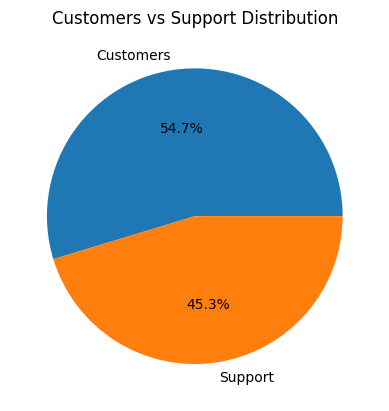

In [ ]:
import matplotlib.pyplot as plt

labels = ['Customers', 'Support']
values = [len(customers), len(support)]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Customers vs Support Distribution")
plt.show()

In [ ]:
merged = customers.merge(
    support,
    left_on='tweet_id',
    right_on='in_response_to_tweet_id',
    how='inner'
)

final_df = merged[['text_x', 'text_y', 'author_id_y']]
final_df.columns = ['question', 'answer', 'company']

In [ ]:
df.head()

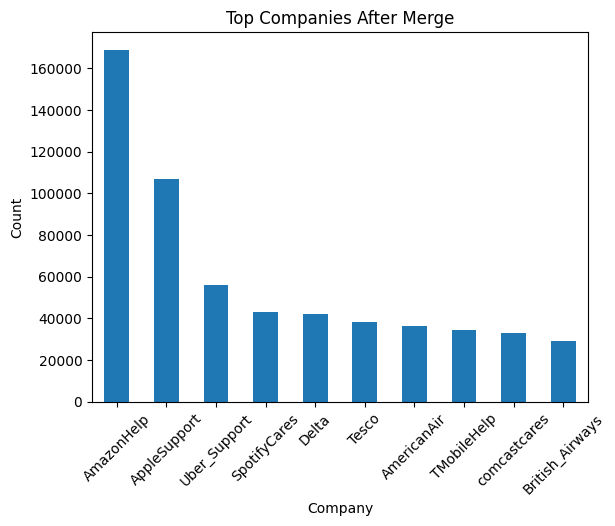

In [ ]:
top_companies = final_df['company'].value_counts().head(10)

plt.figure()
top_companies.plot(kind='bar')
plt.title("Top Companies After Merge")
plt.xlabel("Company")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("Number of Q&A pairs:", len(final_df))

Number of Q&A pairs: 1261888


In [ ]:
final_df.isnull().sum()

,0
question,0
answer,0
company,0


In [ ]:
amazon_df = final_df[final_df['company'] == 'AmazonHelp']

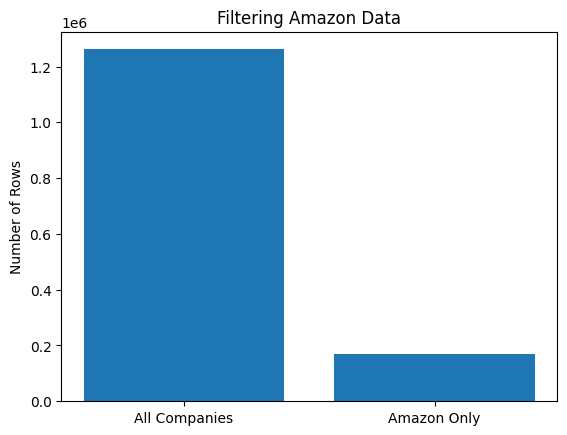

In [ ]:
before = len(final_df)
after = len(amazon_df)

import matplotlib.pyplot as plt

plt.figure()
plt.bar(['All Companies', 'Amazon Only'], [before, after])
plt.title("Filtering Amazon Data")
plt.ylabel("Number of Rows")
plt.show()

In [ ]:
print(amazon_df.head())


                                              question  \
88   @AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎ...   
89                       @AmazonHelp こちらこそありがとうございました。   
90                            amazonのfireTVstickが見れない😢   
113                           amazonプライムビデオ、再生エラーが多いです   
153  @AmazonHelp 3 different people have given 3 di...   

                                                answer     company  
88   @115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました...  AmazonHelp  
89   @115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお...  AmazonHelp  
90   @115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは...  AmazonHelp  
113  @115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の...  AmazonHelp  
153  @115820 We'd like to take a further look into ...  AmazonHelp  


In [ ]:
# !pip install langdetect
# from langdetect import detect

# def is_english(text):
#     try:
#         return detect(text) == 'en'
#     except:
#         return False

# amazon_df = amazon_df[
#     amazon_df['question'].apply(is_english)&
#     amazon_df['answer'].apply(is_english)
# ]

KeyboardInterrupt: 

In [ ]:
# print(len(amazon_df))


123561


In [ ]:
# print(amazon_df.head())

                                              question  \
153  @AmazonHelp 3 different people have given 3 di...   
154  Way to drop the ball on customer service @1158...   
155  @115823 I want my amazon payments account CLOS...   
158  @AmazonHelp @115826 Yeah this is crazy we’re l...   
159  @115828 How about you guys figure out my Xbox ...   

                                                answer     company  
153  @115820 We'd like to take a further look into ...  AmazonHelp  
154  @115820 I'm sorry we've let you down! Without ...  AmazonHelp  
155  @115822 I am unable to affect your account via...  AmazonHelp  
158              @115827 Thanks for your patience. ^KM  AmazonHelp  
159  @115826 I'm sorry for the wait. You'll receive...  AmazonHelp  


In [ ]:
# amazon_df.to_csv("amazon_final_data.csv", index=False)

In [ ]:
# from google.colab import files
# files.download("amazon_final_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Amazon DataSet



##view Data

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
amazon_df=pd.read_csv('/content/amazon_final_data.csv')

In [ ]:
amazon_df.head()

,question,answer,company
0,@AmazonHelp 3 different people have given 3 di...,@115820 We'd like to take a further look into ...,AmazonHelp
1,Way to drop the ball on customer service @1158...,@115820 I'm sorry we've let you down! Without ...,AmazonHelp
2,@115823 I want my amazon payments account CLOS...,@115822 I am unable to affect your account via...,AmazonHelp
3,@AmazonHelp @115826 Yeah this is crazy we’re l...,@115827 Thanks for your patience. ^KM,AmazonHelp
4,@115828 How about you guys figure out my Xbox ...,@115826 I'm sorry for the wait. You'll receive...,AmazonHelp


##Preprocessing

In [ ]:
amazon_df.isnull().sum()

,0
question,0
answer,0
company,0


In [ ]:
amazon_df=amazon_df.drop(columns=['company'])

In [ ]:
amazon_df.duplicated().sum()

np.int64(0)

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

def preprocess(text):
    text = str(text)

    # cleaning
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\^\w+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)

    # tokenization
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [w for w in tokens if w not in stop_words]

    # stemming
    tokens = [stemmer.stem(w) for w in tokens]

    return " ".join(tokens)

amazon_df['question'] = amazon_df['question'].apply(preprocess)
amazon_df['answer'] = amazon_df['answer'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
amazon_df.head()

,question,answer
0,3 different people have given 3 different answ...,wed like to take a further look into this with...
1,way to drop the ball on customer service so pi...,im sorry weve let you down without providing a...
2,i want my amazon payments account closed dm me...,i am unable to affect your account via twitter...
3,yeah this is crazy were less than a week away ...,thanks for your patience
4,how about you guys figure out my xbox one x pr...,im sorry for the wait youll receive an email a...


In [ ]:
sentences = amazon_df['question'].tolist()
!pip install gensim

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

w2v_model.wv['order']

import numpy as np

def sentence_vector(sentence):
    words = sentence.split()
    vectors = []

    for word in words:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

    question_vectors = np.array([
    sentence_vector(q) for q in amazon_df['question']
])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.8 MB/s eta 0:00:00
